# Functions - Images

## Setup

Set up `sys.path` to work while within a subfolder.

In [1]:
import sys
sys.path.append("../..")

Enable this if working within VSCode.

In [2]:
import os

if not os.environ.get("NOTEBOOK_PATH"):
    os.environ["NOTEBOOK_PATH"] = "notebooks/part-1/functions.ipynb"

Manim-related imports.

In [3]:
from manim import *
from manim_utils import *

Set up the image generation cell magic.

In [4]:
%load_ext magics.generate_image

Loaded extension.


## Scenes

### Functions as Machines

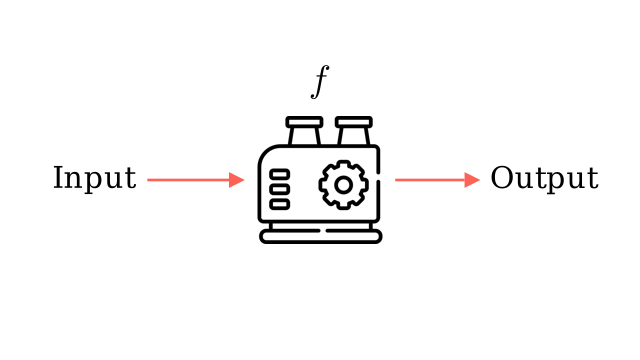

In [5]:
%%generate_image function-as-machine MachineDiagram

ARROW_COLOUR = RED

class MachineDiagram(Scene):
    def construct(self):
        # Create machine
        machine_image = ImageMobject("images/machine.png").scale(0.75)
        machine_label = MathTex("f", font_size=80, color=BLACK).next_to(machine_image, 1.5*UP)
        machine = Group(machine_image, machine_label)
        self.add(machine)

        # Add input
        input_label = Text("Input", color=BLACK)
        input_label.move_to(5*LEFT)
        input_arrow = Arrow(
            input_label.get_right(),
            machine_image.get_left(),
            color=ARROW_COLOUR
        )
        self.add(input_label, input_arrow)

        # Add output
        output_label = Text("Output", color=BLACK)
        output_label.move_to(5*RIGHT)
        output_arrow = Arrow(
            machine_image.get_right(),
            output_label.get_left(),
            color=ARROW_COLOUR
        )
        self.add(output_label, output_arrow)

### The Successor Function
(With the machine analogy.)

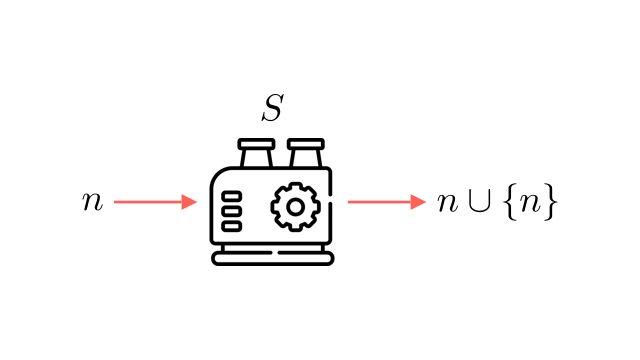

In [6]:
%%generate_image successor-as-machine SuccessorDiagram

ARROW_COLOUR = RED
LABEL_FONT_SIZE = 80

class SuccessorDiagram(Scene):
    def construct(self):
        # Create machine
        machine_image = ImageMobject("images/machine.png").scale(0.75)
        machine_label = MathTex("S", font_size=80, color=BLACK).next_to(machine_image, 1.5*UP)
        machine_group = Group(machine_image, machine_label)

        # Add input
        input_label = MathTex("n", font_size=LABEL_FONT_SIZE, color=BLACK)
        input_label.move_to(4*LEFT)
        input_arrow = Arrow(
            input_label.get_right(),
            machine_image.get_left(),
            color=ARROW_COLOUR
        )
        input_group = Group(input_label, input_arrow)

        # Add output
        output_label = MathTex("n \cup \{n\}", font_size=LABEL_FONT_SIZE, color=BLACK)
        output_label.move_to(5*RIGHT)
        output_arrow = Arrow(
            machine_image.get_right(),
            output_label.get_left(),
            color=ARROW_COLOUR
        )
        output_group = Group(output_label, output_arrow)

        # Center the things
        all_stuff = Group(machine_group, input_group, output_group)
        all_stuff.center()
        self.add(all_stuff)

### The Identity Function

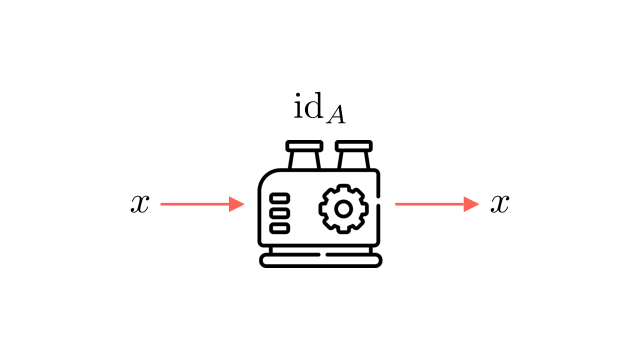

In [7]:
%%generate_image identity-as-machine IdentityFunctionDiagram

ARROW_COLOUR = RED
LABEL_FONT_SIZE = 80

class IdentityFunctionDiagram(Scene):
    def construct(self):
        # Create machine
        machine_image = ImageMobject("images/machine.png").scale(0.75)
        machine_label = MathTex("\mathrm{id}_A", font_size=80, color=BLACK).next_to(machine_image, 1.5*UP)
        machine_group = Group(machine_image, machine_label)

        # Add input
        input_label = MathTex("x", font_size=LABEL_FONT_SIZE, color=BLACK)
        input_label.move_to(4*LEFT)
        input_arrow = Arrow(
            input_label.get_right(),
            machine_image.get_left(),
            color=ARROW_COLOUR
        )
        input_group = Group(input_label, input_arrow)

        # Add output
        output_label = MathTex("x", font_size=LABEL_FONT_SIZE, color=BLACK)
        output_label.move_to(4*RIGHT)
        output_arrow = Arrow(
            machine_image.get_right(),
            output_label.get_left(),
            color=ARROW_COLOUR
        )
        output_group = Group(output_label, output_arrow)

        # Center the things
        all_stuff = Group(machine_group, input_group, output_group)
        all_stuff.center()
        self.add(all_stuff)

### The "Character of" Function
(Using arrow diagram.)

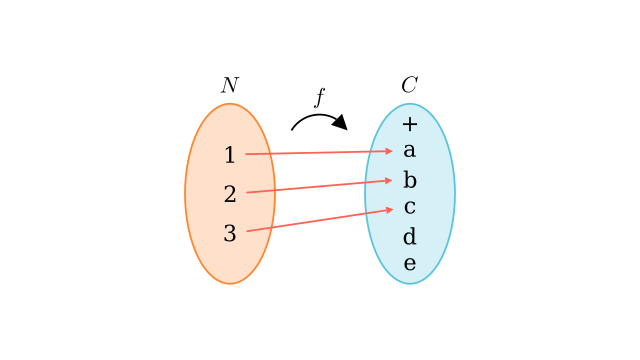

In [8]:
%%generate_image character-of FunctionDiagram

A_FONT_SIZE = 36
B_FONT_SIZE = 36

ARROW_STROKE_WIDTH = 4
ARROW_TIP_RATIO = 0.05

class FunctionDiagram(Scene):
    def construct(self):
        # Create the ellipses
        ellipse_a = Ellipse(width=2, height=4, color=ORANGE)
        ellipse_a.set_fill(ORANGE, opacity=0.25)
        ellipse_a.shift(LEFT * 2)
        
        ellipse_b = Ellipse(width=2, height=4, color=BLUE)
        ellipse_b.set_fill(BLUE, opacity=0.25)
        ellipse_b.shift(RIGHT * 2)
        
        # Create labels for the ellipses
        label_a = MathTex("N", color=BLACK).next_to(ellipse_a, UP)
        label_b = MathTex("C", color=BLACK).next_to(ellipse_b, UP)
        
        # Create elements for sets
        elements_a = ["1", "2", "3"]
        elements_b = ["+", "a", "b", "c", "d", "e"]

        elements_a = [Text(a, font_size=A_FONT_SIZE, color=BLACK) for a in elements_a]
        elements_b = [Text(b, font_size=B_FONT_SIZE, color=BLACK) for b in elements_b]
        
        elements_a = VGroup(*elements_a).arrange(DOWN, buff=0.5).move_to(ellipse_a)
        elements_b = VGroup(*elements_b).arrange(DOWN, buff=0.3).move_to(ellipse_b)
        
        # Create arrows
        arrow_links = [
            (0,1),
            (1,2),
            (2,3)
        ]
        arrows = [
            Arrow(
                elements_a[i].get_right(),
                elements_b[j].get_left(),
                stroke_width=ARROW_STROKE_WIDTH,
                max_tip_length_to_length_ratio=ARROW_TIP_RATIO,
                color=RED
            )
            for i, j in arrow_links
        ]
        arrows = VGroup(*arrows)

        # Add function label above the arrows
        function_label = MathTex("f", color=BLACK).next_to(arrows, 3.5*UP)
        function_label.add(
            CurvedArrow(
                function_label.get_left() + LEFT * 0.5,
                function_label.get_right() + RIGHT * 0.5,
                stroke_width=ARROW_STROKE_WIDTH,
                color=BLACK
            ).flip(LEFT).shift(DOWN * 0.35)
        )

        # Add all elements to the scene
        group = Group(ellipse_a, ellipse_b, label_a, label_b, elements_a, elements_b, arrows, function_label)
        group.center()
        self.add(group)

### The Successor Function
(Using arrow diagram.)

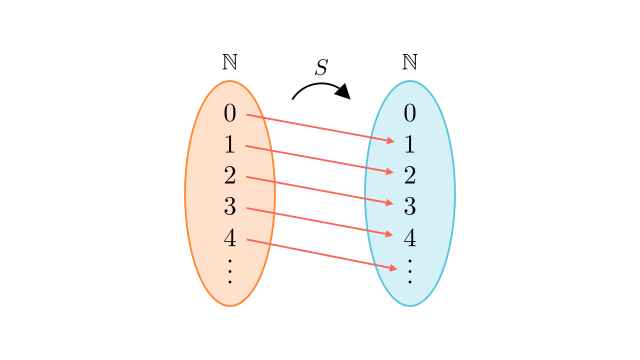

In [9]:
%%generate_image successor FunctionDiagram

A_FONT_SIZE = 56  # NOTE: This is font size using TeX
B_FONT_SIZE = 56

ARROW_STROKE_WIDTH = 4
ARROW_TIP_RATIO = 0.05

class FunctionDiagram(Scene):
    def construct(self):
        # Create the ellipses
        ellipse_a = Ellipse(width=2, height=5, color=ORANGE)
        ellipse_a.set_fill(ORANGE, opacity=0.25)
        ellipse_a.shift(LEFT * 2)
        
        ellipse_b = Ellipse(width=2, height=5, color=BLUE)
        ellipse_b.set_fill(BLUE, opacity=0.25)
        ellipse_b.shift(RIGHT * 2)
        
        # Create labels for the ellipses
        label_a = MathTex("\mathbb{N}", color=BLACK).next_to(ellipse_a, UP)
        label_b = MathTex("\mathbb{N}", color=BLACK).next_to(ellipse_b, UP)
        
        # Create elements for sets
        elements_a = ["0", "1", "2", "3", "4", "\\vdots"]
        elements_b = ["0", "1", "2", "3", "4", "\\vdots"]

        elements_a = [Tex(a, font_size=A_FONT_SIZE, color=BLACK) for a in elements_a]
        elements_b = [Tex(b, font_size=B_FONT_SIZE, color=BLACK) for b in elements_b]
        
        elements_a = VGroup(*elements_a).arrange(DOWN, buff=0.3).move_to(ellipse_a)
        elements_b = VGroup(*elements_b).arrange(DOWN, buff=0.3).move_to(ellipse_b)
        
        # Create arrows
        arrow_links = [
            (0,1),
            (1,2),
            (2,3),
            (3,4),
            (4,5)
        ]
        arrows = [
            Arrow(
                elements_a[i].get_right(),
                elements_b[j].get_left(),
                stroke_width=ARROW_STROKE_WIDTH,
                max_tip_length_to_length_ratio=ARROW_TIP_RATIO,
                color=RED
            )
            for i, j in arrow_links
        ]
        arrows = VGroup(*arrows)

        # Add function label above the arrows
        function_label = MathTex("S", color=BLACK).next_to(arrows, 3.5*UP)
        function_label.add(
            CurvedArrow(
                function_label.get_left() + LEFT * 0.5,
                function_label.get_right() + RIGHT * 0.5,
                stroke_width=ARROW_STROKE_WIDTH,
                color=BLACK
            ).flip(LEFT).shift(DOWN * 0.35)
        )

        # Add all elements to the scene
        group = Group(ellipse_a, ellipse_b, label_a, label_b, elements_a, elements_b, arrows, function_label)
        group.center()
        self.add(group)

### A Function's Properties
(Exercise.)

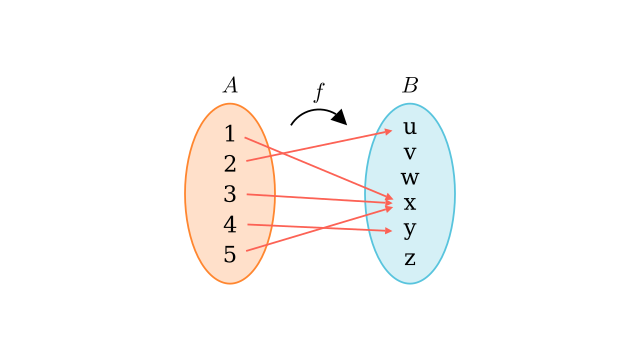

In [10]:
%%generate_image a-functions-properties FunctionDiagram

A_FONT_SIZE = 36
B_FONT_SIZE = 36

ARROW_STROKE_WIDTH = 4
ARROW_TIP_RATIO = 0.05

class FunctionDiagram(Scene):
    def construct(self):
        # Create the ellipses
        ellipse_a = Ellipse(width=2, height=4, color=ORANGE)
        ellipse_a.set_fill(ORANGE, opacity=0.25)
        ellipse_a.shift(LEFT * 2)
        
        ellipse_b = Ellipse(width=2, height=4, color=BLUE)
        ellipse_b.set_fill(BLUE, opacity=0.25)
        ellipse_b.shift(RIGHT * 2)
        
        # Create labels for the ellipses
        label_a = MathTex("A", color=BLACK).next_to(ellipse_a, UP)
        label_b = MathTex("B", color=BLACK).next_to(ellipse_b, UP)
        
        # Create elements for sets
        elements_a = ["1", "2", "3", "4", "5"]
        elements_b = ["u", "v", "w", "x", "y", "z"]

        elements_a = [Text(a, font_size=A_FONT_SIZE, color=BLACK) for a in elements_a]
        elements_b = [Text(b, font_size=B_FONT_SIZE, color=BLACK) for b in elements_b]
        
        elements_a = VGroup(*elements_a).arrange(DOWN, buff=0.3).move_to(ellipse_a)
        elements_b = VGroup(*elements_b).arrange(DOWN, buff=0.3).move_to(ellipse_b)
        
        # Create arrows
        arrow_links = [
            (0,3),
            (1,0),
            (2,3),
            (3,4),
            (4,3)
        ]
        arrows = [
            Arrow(
                elements_a[i].get_right(),
                elements_b[j].get_left(),
                stroke_width=ARROW_STROKE_WIDTH,
                max_tip_length_to_length_ratio=ARROW_TIP_RATIO,
                color=RED
            )
            for i, j in arrow_links
        ]
        arrows = VGroup(*arrows)

        # Add function label above the arrows
        function_label = MathTex("f", color=BLACK).next_to(arrows, 2.25*UP)
        function_label.add(
            CurvedArrow(
                function_label.get_left() + LEFT * 0.5,
                function_label.get_right() + RIGHT * 0.5,
                stroke_width=ARROW_STROKE_WIDTH,
                color=BLACK
            ).flip(LEFT).shift(DOWN * 0.35)
        )

        # Add all elements to the scene
        group = Group(ellipse_a, ellipse_b, label_a, label_b, elements_a, elements_b, arrows, function_label)
        group.center()
        self.add(group)

### The "Character of" Function
(As a surjective function.)

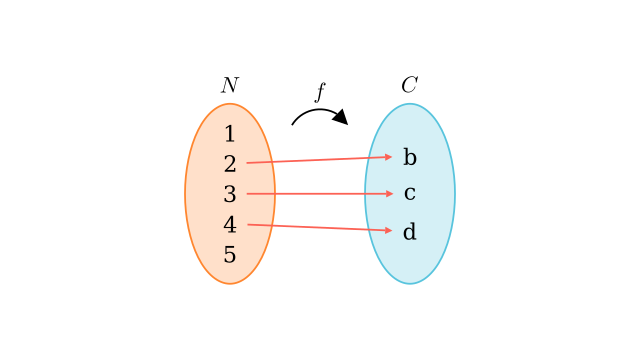

In [11]:
%%generate_image character-of_surjective FunctionDiagram

A_FONT_SIZE = 36
B_FONT_SIZE = 36

ARROW_STROKE_WIDTH = 4
ARROW_TIP_RATIO = 0.05

class FunctionDiagram(Scene):
    def construct(self):
        # Create the ellipses
        ellipse_a = Ellipse(width=2, height=4, color=ORANGE)
        ellipse_a.set_fill(ORANGE, opacity=0.25)
        ellipse_a.shift(LEFT * 2)
        
        ellipse_b = Ellipse(width=2, height=4, color=BLUE)
        ellipse_b.set_fill(BLUE, opacity=0.25)
        ellipse_b.shift(RIGHT * 2)
        
        # Create labels for the ellipses
        label_a = MathTex("N", color=BLACK).next_to(ellipse_a, UP)
        label_b = MathTex("C", color=BLACK).next_to(ellipse_b, UP)
        
        # Create elements for sets
        elements_a = ["1", "2", "3", "4", "5"]
        elements_b = ["b", "c", "d"]

        elements_a = [Text(a, font_size=A_FONT_SIZE, color=BLACK) for a in elements_a]
        elements_b = [Text(b, font_size=B_FONT_SIZE, color=BLACK) for b in elements_b]
        
        elements_a = VGroup(*elements_a).arrange(DOWN, buff=0.3).move_to(ellipse_a)
        elements_b = VGroup(*elements_b).arrange(DOWN, buff=0.5).move_to(ellipse_b)
        
        # Create arrows
        arrow_links = [
            (1, 0),
            (2, 1),
            (3, 2)
        ]
        arrows = [
            Arrow(
                elements_a[i].get_right(),
                elements_b[j].get_left(),
                stroke_width=ARROW_STROKE_WIDTH,
                max_tip_length_to_length_ratio=ARROW_TIP_RATIO,
                color=RED
            )
            for i, j in arrow_links
        ]
        arrows = VGroup(*arrows)

        # Add function label above the arrows
        function_label = MathTex("f", color=BLACK).next_to(arrows, 4.5*UP)
        function_label.add(
            CurvedArrow(
                function_label.get_left() + LEFT * 0.5,
                function_label.get_right() + RIGHT * 0.5,
                stroke_width=ARROW_STROKE_WIDTH,
                color=BLACK
            ).flip(LEFT).shift(DOWN * 0.35)
        )

        # Add all elements to the scene
        group = Group(ellipse_a, ellipse_b, label_a, label_b, elements_a, elements_b, arrows, function_label)
        group.center()
        self.add(group)

### Injective/Surjective Detective
(Functions for the exercises.)

Common constants.

In [12]:
ARROW_STROKE_WIDTH = 4
ARROW_TIP_RATIO = 0.05

FONT_SIZE = 36

Helper function that generates the items for a set.

In [13]:
def generate_ellipse(size: int, label: str, colour: ManimColor, buff: float = 0.35) -> VGroup:
    # Generate ellipse
    ellipse = Ellipse(width=2, height=4, color=colour)
    ellipse.set_fill(colour, opacity=0.25)

    # Create labels for the ellipses
    label = MathTex(label, color=BLACK).next_to(ellipse, UP)
    
    # Generate elements
    elements = [Text(str(i), font_size=FONT_SIZE, color=BLACK) for i in range(size)]
    elements = VGroup(*elements).arrange(DOWN, buff=buff).move_to(ellipse)

    # Place both in one group
    ellipse = VGroup(ellipse, label, elements)
    return ellipse

Helper function that generates the arrows.

In [14]:
def generate_arrows(ellipse_a: VGroup, ellipse_b: VGroup, links: list[tuple[int, int]]):
    arrows = [
        Arrow(
            ellipse_a[2][i].get_right(),
            ellipse_b[2][j].get_left(),
            stroke_width=ARROW_STROKE_WIDTH,
            max_tip_length_to_length_ratio=ARROW_TIP_RATIO,
            color=RED
        )
        for i, j in links
    ]
    arrows = VGroup(*arrows)
    return arrows

Helper function that creates the class for a specific combination of set sizes and set links.

In [15]:
def make_detective(a_size: int, b_size: int, links: list[tuple[int, int]], a_buff: float = 0.35, b_buff: float = 0.35):
    class FunctionDiagram(Scene):
        def construct(self):
            # Create the ellipses
            ellipse_a = generate_ellipse(a_size, "A", ORANGE, buff=a_buff).shift(2*LEFT)
            ellipse_b = generate_ellipse(b_size, "B", BLUE, buff=b_buff).shift(2*RIGHT)
    
            self.add(ellipse_a, ellipse_b)
    
            # Create arrows
            arrows = generate_arrows(ellipse_a, ellipse_b, links)
            self.add(arrows)
            
            # Add function label above the arrows
            function_label = MathTex("f", color=BLACK).shift(2.25*UP)
            function_label.add(
                CurvedArrow(
                    function_label.get_left() + LEFT * 0.5,
                    function_label.get_right() + RIGHT * 0.5,
                    stroke_width=ARROW_STROKE_WIDTH,
                    color=BLACK
                ).flip(LEFT).shift(DOWN * 0.35)
            )
            self.add(function_label)
    
    return FunctionDiagram

#### Injective Detective

Non-injective 1.

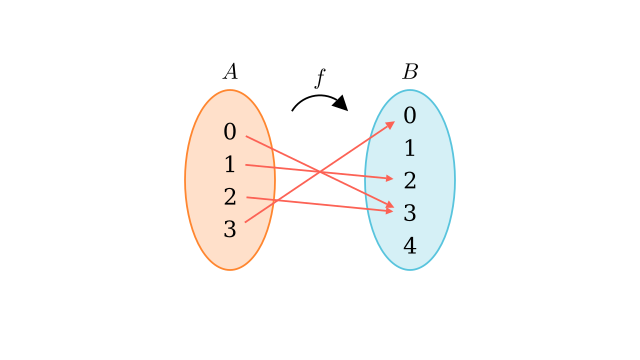

In [16]:
%%generate_image surjective-detective_noninj_1 DetectiveDiagram

DetectiveDiagram = make_detective(
    4,
    5, 
    [
        (0, 3),
        (1, 2),
        (2, 3),
        (3, 0)
    ]
)

Non-injective 2.

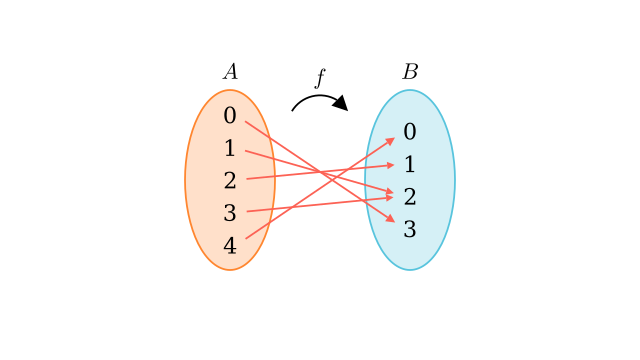

In [17]:
%%generate_image surjective-detective_noninj_2 DetectiveDiagram

DetectiveDiagram = make_detective(
    5,
    4, 
    [
        (0, 3),
        (1, 2),
        (2, 1),
        (3, 2),
        (4, 0)
    ]
)

Injective 1.

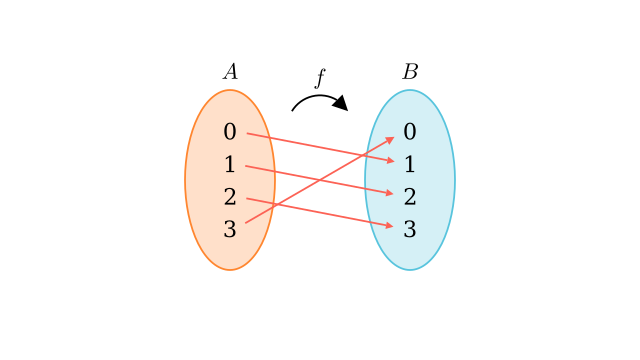

In [18]:
%%generate_image surjective-detective_yesinj_1 DetectiveDiagram

DetectiveDiagram = make_detective(
    4,
    4, 
    [
        (0, 1),
        (1, 2),
        (2, 3),
        (3, 0)
    ]
)

Injective 2.

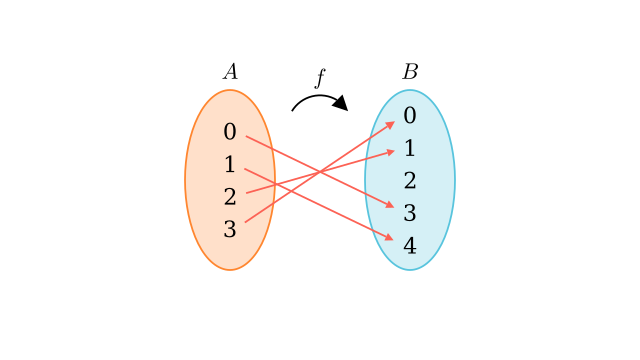

In [19]:
%%generate_image surjective-detective_yesinj_2 DetectiveDiagram

DetectiveDiagram = make_detective(
    4,
    5, 
    [
        (0, 3),
        (1, 4),
        (2, 1),
        (3, 0),
    ]
)

#### Surjective Detective

Non-surjective 1.

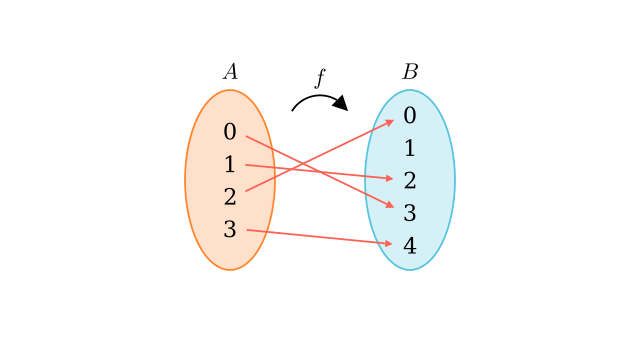

In [20]:
%%generate_image surjective-detective_nonsurj_1 DetectiveDiagram

DetectiveDiagram = make_detective(
    4,
    5, 
    [
        (0, 3),
        (1, 2),
        (2, 0),
        (3, 4)
    ]
)

Non-surjective 2.

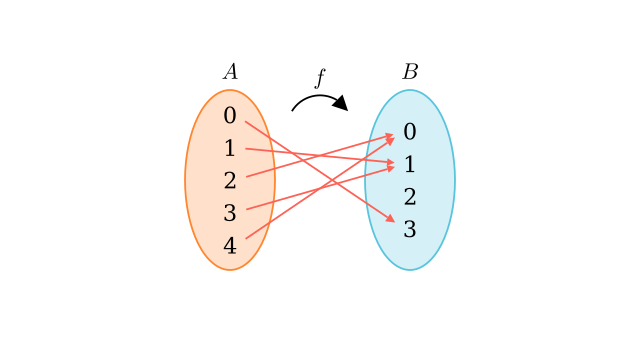

In [21]:
%%generate_image surjective-detective_nonsurj_2 DetectiveDiagram

DetectiveDiagram = make_detective(
    5,
    4, 
    [
        (0, 3),
        (1, 1),
        (2, 0),
        (3, 1),
        (4, 0)
    ]
)

Surjective 1.

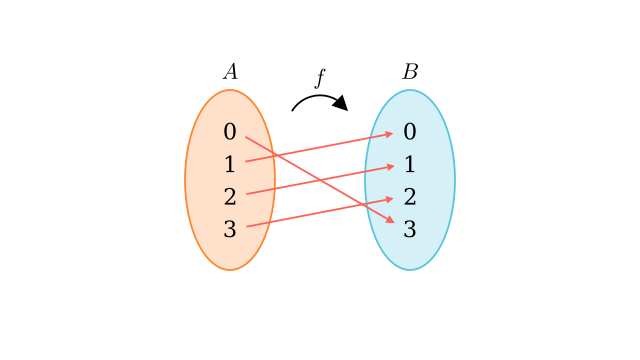

In [22]:
%%generate_image surjective-detective_yessurj_1 DetectiveDiagram

DetectiveDiagram = make_detective(
    4,
    4, 
    [
        (0, 3),
        (1, 0),
        (2, 1),
        (3, 2)
    ]
)

Surjective 2.

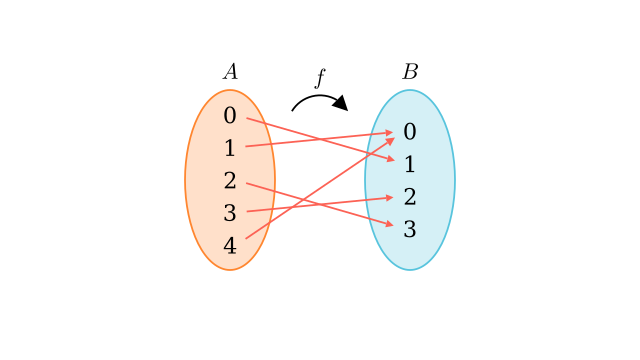

In [23]:
%%generate_image surjective-detective_yessurj_2 DetectiveDiagram

DetectiveDiagram = make_detective(
    5,
    4, 
    [
        (0, 1),
        (1, 0),
        (2, 3),
        (3, 2),
        (4, 0)
    ]
)

### The "Decimal to Binary"/"Binary to Decimal" Functions

Decimal to binary.

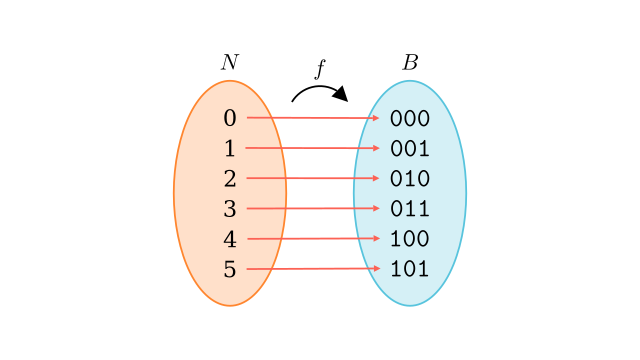

In [32]:
%%generate_image decimal-to-binary FunctionDiagram

A_FONT_SIZE = 36  # Normal text font size
B_FONT_SIZE = 56  # TeX font size

ARROW_STROKE_WIDTH = 4
ARROW_TIP_RATIO = 0.05

class FunctionDiagram(Scene):
    def construct(self):
        # Create the ellipses
        ellipse_a = Ellipse(width=2.5, height=5, color=ORANGE)
        ellipse_a.set_fill(ORANGE, opacity=0.25)
        ellipse_a.shift(LEFT * 2)
        
        ellipse_b = Ellipse(width=2.5, height=5, color=BLUE)
        ellipse_b.set_fill(BLUE, opacity=0.25)
        ellipse_b.shift(RIGHT * 2)
        
        # Create labels for the ellipses
        label_a = MathTex("N", color=BLACK).next_to(ellipse_a, UP)
        label_b = MathTex("B", color=BLACK).next_to(ellipse_b, UP)
        
        # Create elements for sets
        elements_a = ["0", "1", "2", "3", "4", "5"]
        elements_b = ["\\texttt{000}", "\\texttt{001}", "\\texttt{010}", "\\texttt{011}", "\\texttt{100}", "\\texttt{101}"]

        elements_a = [Text(a, font_size=A_FONT_SIZE, color=BLACK) for a in elements_a]
        elements_b = [Tex(b, font_size=B_FONT_SIZE, color=BLACK) for b in elements_b]
        
        elements_a = VGroup(*elements_a).arrange(DOWN, buff=0.3).move_to(ellipse_a)
        elements_b = VGroup(*elements_b).arrange(DOWN, buff=0.3).move_to(ellipse_b)
        
        # Create arrows
        arrow_links = [(i,i) for i in range(6)]
        arrows = [
            Arrow(
                elements_a[i].get_right(),
                elements_b[j].get_left(),
                stroke_width=ARROW_STROKE_WIDTH,
                max_tip_length_to_length_ratio=ARROW_TIP_RATIO,
                color=RED
            )
            for i, j in arrow_links
        ]
        arrows = VGroup(*arrows)

        # Add function label above the arrows
        function_label = MathTex("f", color=BLACK).move_to(2.75*UP)
        function_label.add(
            CurvedArrow(
                function_label.get_left() + LEFT * 0.5,
                function_label.get_right() + RIGHT * 0.5,
                stroke_width=ARROW_STROKE_WIDTH,
                color=BLACK
            ).flip(LEFT).shift(DOWN * 0.35)
        )

        # Add all elements to the scene
        group = Group(ellipse_a, ellipse_b, label_a, label_b, elements_a, elements_b, arrows, function_label)
        group.center()
        self.add(group)

Binary to decimal.

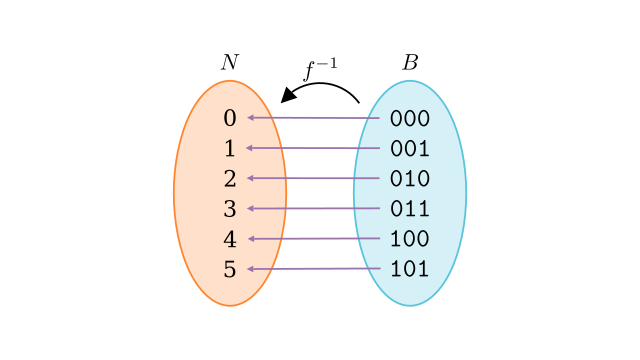

In [37]:
%%generate_image binary-to-decimal FunctionDiagram

A_FONT_SIZE = 36  # Normal text font size
B_FONT_SIZE = 56  # TeX font size

ARROW_STROKE_WIDTH = 4
ARROW_TIP_RATIO = 0.05

class FunctionDiagram(Scene):
    def construct(self):
        # Create the ellipses
        ellipse_a = Ellipse(width=2.5, height=5, color=ORANGE)
        ellipse_a.set_fill(ORANGE, opacity=0.25)
        ellipse_a.shift(LEFT * 2)
        
        ellipse_b = Ellipse(width=2.5, height=5, color=BLUE)
        ellipse_b.set_fill(BLUE, opacity=0.25)
        ellipse_b.shift(RIGHT * 2)
        
        # Create labels for the ellipses
        label_a = MathTex("N", color=BLACK).next_to(ellipse_a, UP)
        label_b = MathTex("B", color=BLACK).next_to(ellipse_b, UP)
        
        # Create elements for sets
        elements_a = ["0", "1", "2", "3", "4", "5"]
        elements_b = ["\\texttt{000}", "\\texttt{001}", "\\texttt{010}", "\\texttt{011}", "\\texttt{100}", "\\texttt{101}"]

        elements_a = [Text(a, font_size=A_FONT_SIZE, color=BLACK) for a in elements_a]
        elements_b = [Tex(b, font_size=B_FONT_SIZE, color=BLACK) for b in elements_b]
        
        elements_a = VGroup(*elements_a).arrange(DOWN, buff=0.3).move_to(ellipse_a)
        elements_b = VGroup(*elements_b).arrange(DOWN, buff=0.3).move_to(ellipse_b)
        
        # Create arrows
        arrow_links = [(i,i) for i in range(6)]
        arrows = [
            Arrow(
                # I just swap the arrows
                elements_b[j].get_left(),
                elements_a[i].get_right(),
                stroke_width=ARROW_STROKE_WIDTH,
                max_tip_length_to_length_ratio=ARROW_TIP_RATIO,
                color=PURPLE
            )
            for i, j in arrow_links
        ]
        arrows = VGroup(*arrows)

        # Add function label above the arrows
        function_label = MathTex("f^{-1}", color=BLACK).move_to(2.75*UP)
        function_label.add(
            CurvedArrow(
                function_label.get_right() + RIGHT * 0.5,
                function_label.get_left() + LEFT * 0.5,
                stroke_width=ARROW_STROKE_WIDTH,
                color=BLACK
            ).shift(DOWN * 0.75)
        )

        # Add all elements to the scene
        group = Group(ellipse_a, ellipse_b, label_a, label_b, elements_a, elements_b, arrows, function_label)
        group.center()
        self.add(group)

### Composition of Functions


As machines.

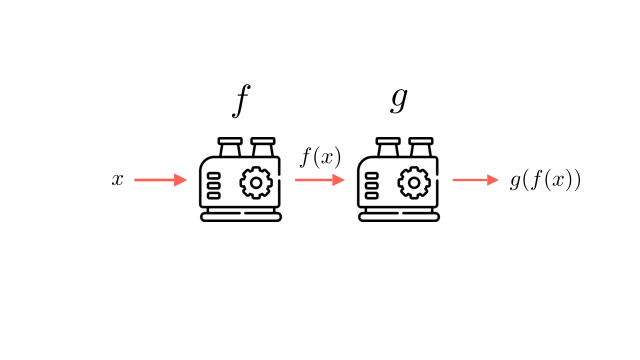

In [43]:
%%generate_image function-composition_machine MachineDiagram

ARROW_COLOUR = RED

class MachineDiagram(Scene):
    def construct(self):
        # Create machines
        machine_image_1 = ImageMobject("images/machine.png").scale(0.5).move_to(1.75*LEFT)
        machine_image_2 = ImageMobject("images/machine.png").scale(0.5).move_to(1.75*RIGHT)
        machine_label_1 = MathTex("f", font_size=80, color=BLACK).move_to(1.75*LEFT + 1.75*UP)
        machine_label_2 = MathTex("g", font_size=80, color=BLACK).move_to(1.75*RIGHT + 1.75*UP)
        
        self.add(machine_image_1, machine_label_1, machine_image_2, machine_label_2)

        # Add input
        input_label = MathTex("x", color=BLACK)
        input_label.move_to(4.5*LEFT)
        input_arrow = Arrow(
            input_label.get_right(),
            machine_image_1.get_left(),
            color=ARROW_COLOUR
        )
        self.add(input_label, input_arrow)

        # Add intermediate
        intermediate_label = MathTex("f(x)", color=BLACK)
        intermediate_label.move_to(0.5*UP)
        intermediate_arrow = Arrow(
            machine_image_1.get_right(),
            machine_image_2.get_left(),
            color=ARROW_COLOUR
        )
        self.add(intermediate_label, intermediate_arrow)

        # Add output
        output_label = MathTex("g(f(x))", color=BLACK)
        output_label.move_to(5*RIGHT)
        output_arrow = Arrow(
            machine_image_2.get_right(),
            output_label.get_left(),
            color=ARROW_COLOUR
        )
        self.add(output_label, output_arrow)

As arrow diagram.

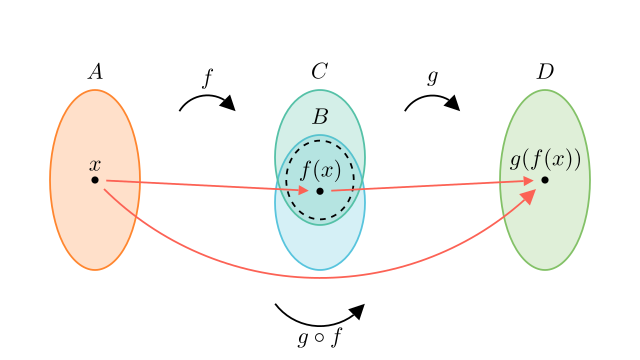

In [122]:
%%generate_image function-composition_arrow-diagram FunctionDiagram --temp-dir temp

A_FONT_SIZE = 28
A_COLOUR = ORANGE
B_FONT_SIZE = 28
B_COLOUR = BLUE
C_FONT_SIZE = 28
C_COLOUR = TEAL_D
D_FONT_SIZE = 28
D_COLOUR = GREEN
R_COLOUR = BLACK  # Range

ARROW_STROKE_WIDTH = 4
ARROW_TIP_RATIO = 0.05
ARROW_COLOUR = RED

class FunctionDiagram(Scene):
    def construct(self):
        # Create the ellipses
        ellipse_a = Ellipse(width=2, height=4, color=A_COLOUR)
        ellipse_a.set_fill(A_COLOUR, opacity=0.25)
        ellipse_a.shift(5 * LEFT)
        
        ellipse_b = Ellipse(width=2, height=3, color=B_COLOUR)
        ellipse_b.set_fill(B_COLOUR, opacity=0.25)
        ellipse_b.shift(0.5 * DOWN)

        ellipse_c = Ellipse(width=2, height=3, color=C_COLOUR)
        ellipse_c.set_fill(C_COLOUR, opacity=0.25)
        ellipse_c.shift(0.5 *UP)

        ellipse_d = Ellipse(width=2, height=4, color=D_COLOUR)
        ellipse_d.set_fill(D_COLOUR, opacity=0.25)
        ellipse_d.shift(5 * RIGHT)

        ellipse_r = DashedVMobject(Ellipse(width=1.5, height=1.75, color=R_COLOUR), num_dashes=20)
        ellipse_r.set_fill(R_COLOUR, opacity=0.25)

        self.add(ellipse_a, ellipse_b, ellipse_c, ellipse_d, ellipse_r)
        
        # Create labels for the ellipses
        label_a = MathTex("A", color=BLACK).next_to(ellipse_a, UP)
        label_b = MathTex("B", color=BLACK).next_to(ellipse_b, UP)
        label_c = MathTex("C", color=BLACK).next_to(ellipse_c, UP)
        label_d = MathTex("D", color=BLACK).next_to(ellipse_d, UP)

        self.add(label_a, label_b, label_c, label_d)

        # Add function labels
        f_label = MathTex("f", color=BLACK).move_to(2.5*LEFT + 2.25*UP)
        f_label.add(
            CurvedArrow(
                f_label.get_left() + LEFT * 0.5,
                f_label.get_right() + RIGHT * 0.5,
                stroke_width=ARROW_STROKE_WIDTH,
                color=BLACK
            ).flip(LEFT).shift(DOWN * 0.35)
        )

        g_label = MathTex("g", color=BLACK).move_to(2.5*RIGHT + 2.25*UP)
        g_label.add(
            CurvedArrow(
                g_label.get_left() + LEFT * 0.5,
                g_label.get_right() + RIGHT * 0.5,
                stroke_width=ARROW_STROKE_WIDTH,
                color=BLACK
            ).flip(LEFT).shift(DOWN * 0.35)
        )

        gf_label = MathTex("g \\circ f", color=BLACK).move_to(3.5*DOWN)
        gf_label.add(
            CurvedArrow(
                gf_label.get_left() + LEFT * 0.5,
                gf_label.get_right() + RIGHT * 0.5,
                stroke_width=ARROW_STROKE_WIDTH,
                color=BLACK
            ).shift(UP * 0.75)
        )

        self.add(f_label, g_label, gf_label)
        
        # Create element in A
        x_dot = Dot(color=BLACK).move_to(5*LEFT)
        x_label = MathTex(
            "x", color=BLACK
        ).next_to(x_dot, 0.5*UP)
        x = Group(x_dot, x_label)
        self.add(x)

        # Create mapped element in B/C
        fx_dot = Dot(color=BLACK).shift(0.25*DOWN)
        fx_label =  MathTex(
            "f(x)", color=BLACK
        ).next_to(fx_dot, 0.5*UP)
        fx = Group(fx_dot, fx_label)
        self.add(fx)

        # Create final element in D
        gfx_dot = Dot(color=BLACK).move_to(5*RIGHT)
        gfx_label =  MathTex(
            "g(f(x))", color=BLACK
        ).next_to(gfx_dot, 0.5*UP)
        gfx = Group(gfx_dot, gfx_label)
        self.add(gfx)
        
        # Add arrows
        x_fx = Arrow(
            x_dot.get_center(),
            fx_dot.get_center(),
            stroke_width=ARROW_STROKE_WIDTH,
            max_tip_length_to_length_ratio=ARROW_TIP_RATIO,
            color=ARROW_COLOUR
        )
        
        fx_gfx = Arrow(
            fx_dot.get_center(),
            gfx_dot.get_center(),
            stroke_width=ARROW_STROKE_WIDTH,
            max_tip_length_to_length_ratio=ARROW_TIP_RATIO,
            color=ARROW_COLOUR
        )
        
        x_gfx = CurvedArrow(
            x_dot.get_center() + 0.2*(DOWN+RIGHT),
            gfx_dot.get_center() + 0.2*(DOWN+LEFT),
            stroke_width=ARROW_STROKE_WIDTH,
            color=ARROW_COLOUR,
            radius=7
        )

        self.add(x_fx, fx_gfx, x_gfx)

### Composing an Invertible Function with Its Inverse

The function $f$.

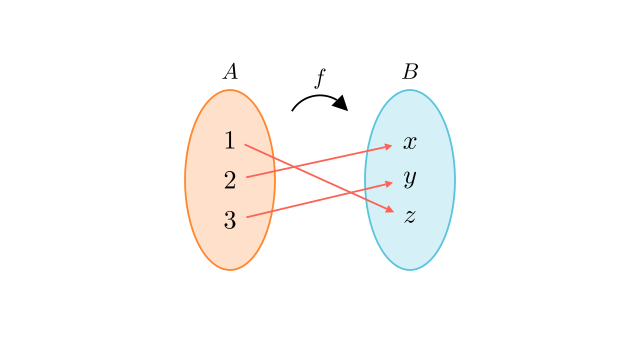

In [26]:
%%generate_image compose-function-with-inverse_f FunctionDiagram

A_FONT_SIZE = 56  # TeX font size
A_COLOUR = ORANGE
B_FONT_SIZE = 56
B_COLOUR = BLUE

ARROW_STROKE_WIDTH = 4
ARROW_TIP_RATIO = 0.05
ARROW_COLOUR = RED

class FunctionDiagram(Scene):
    def construct(self):
        # Create the ellipses
        ellipse_a = Ellipse(width=2, height=4, color=A_COLOUR)
        ellipse_a.set_fill(A_COLOUR, opacity=0.25)
        ellipse_a.shift(2 * LEFT)
        
        ellipse_b = Ellipse(width=2, height=4, color=B_COLOUR)
        ellipse_b.set_fill(B_COLOUR, opacity=0.25)
        ellipse_b.shift(2 * RIGHT)

        self.add(ellipse_a, ellipse_b)
        
        # Create labels for the ellipses
        label_a = MathTex("A", color=BLACK).next_to(ellipse_a, UP)
        label_b = MathTex("B", color=BLACK).next_to(ellipse_b, UP)

        self.add(label_a, label_b)

        # Add function label
        f_label = MathTex("f", color=BLACK).move_to(2.25*UP)
        f_label.add(
            CurvedArrow(
                f_label.get_left() + LEFT * 0.5,
                f_label.get_right() + RIGHT * 0.5,
                stroke_width=ARROW_STROKE_WIDTH,
                color=BLACK
            ).flip(LEFT).shift(DOWN * 0.35)
        )

        self.add(f_label)

        # Create elements for sets
        elements_a = ["1", "2", "3"]
        elements_b = ["x", "y", "z"]

        elements_a = [MathTex(a, font_size=A_FONT_SIZE, color=BLACK) for a in elements_a]
        elements_b = [MathTex(b, font_size=B_FONT_SIZE, color=BLACK) for b in elements_b]
        
        elements_a = VGroup(*elements_a).arrange(DOWN, buff=0.5).move_to(ellipse_a)
        elements_b = VGroup(*elements_b).arrange(DOWN, buff=0.5).move_to(ellipse_b)

        self.add(elements_a, elements_b)
        
        # Create arrows
        arrow_links = [
            (0,2),
            (1,0),
            (2,1)
        ]
        arrows = [
            Arrow(
                elements_a[i].get_right(),
                elements_b[j].get_left(),
                stroke_width=ARROW_STROKE_WIDTH,
                max_tip_length_to_length_ratio=ARROW_TIP_RATIO,
                color=RED
            )
            for i, j in arrow_links
        ]
        self.add(VGroup(*arrows))

The inverse function $f^{-1}$.

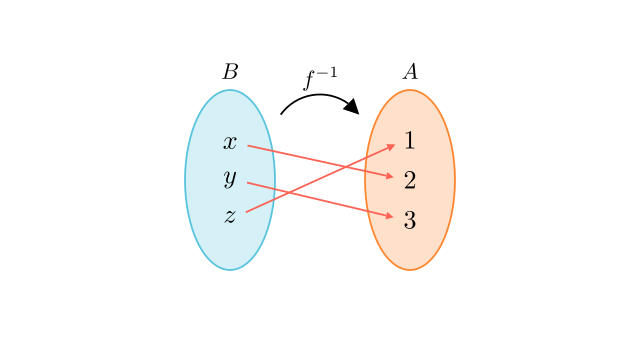

In [27]:
%%generate_image compose-function-with-inverse_f-inv FunctionDiagram

A_FONT_SIZE = 56  # TeX font size
A_COLOUR = ORANGE
B_FONT_SIZE = 56
B_COLOUR = BLUE

ARROW_STROKE_WIDTH = 4
ARROW_TIP_RATIO = 0.05
ARROW_COLOUR = RED

class FunctionDiagram(Scene):
    def construct(self):
        # Create the ellipses
        ellipse_b = Ellipse(width=2, height=4, color=B_COLOUR)
        ellipse_b.set_fill(B_COLOUR, opacity=0.25)
        ellipse_b.shift(2 * LEFT)

        ellipse_a = Ellipse(width=2, height=4, color=A_COLOUR)
        ellipse_a.set_fill(A_COLOUR, opacity=0.25)
        ellipse_a.shift(2 * RIGHT)

        self.add(ellipse_b, ellipse_a)
        
        # Create labels for the ellipses
        label_b = MathTex("B", color=BLACK).next_to(ellipse_b, UP)
        label_a = MathTex("A", color=BLACK).next_to(ellipse_a, UP)

        self.add(label_b, label_a)

        # Add function label
        fi_label = MathTex("f^{-1}", color=BLACK).move_to(2.25*UP)
        fi_label.add(
            CurvedArrow(
                fi_label.get_left() + LEFT * 0.5,
                fi_label.get_right() + RIGHT * 0.5,
                stroke_width=ARROW_STROKE_WIDTH,
                color=BLACK
            ).flip(LEFT).shift(DOWN * 0.35)
        )

        self.add(fi_label)

        # Create elements for sets
        elements_a = ["1", "2", "3"]
        elements_b = ["x", "y", "z"]

        elements_a = [MathTex(a, font_size=A_FONT_SIZE, color=BLACK) for a in elements_a]
        elements_b = [MathTex(b, font_size=B_FONT_SIZE, color=BLACK) for b in elements_b]
        
        elements_a = VGroup(*elements_a).arrange(DOWN, buff=0.5).move_to(ellipse_a)
        elements_b = VGroup(*elements_b).arrange(DOWN, buff=0.5).move_to(ellipse_b)

        self.add(elements_a, elements_b)
        
        # Create arrows (note these are for the function f; we will reverse them later)
        arrow_links = [
            (0,2),
            (1,0),
            (2,1)
        ]
        arrows = [
            Arrow(
                elements_b[j].get_right(),
                elements_a[i].get_left(),
                stroke_width=ARROW_STROKE_WIDTH,
                max_tip_length_to_length_ratio=ARROW_TIP_RATIO,
                color=RED
            )
            for i, j in arrow_links
        ]
        self.add(VGroup(*arrows))

Composition going $A \to B \to A$ (i.e., $f^{-1} \circ f$).

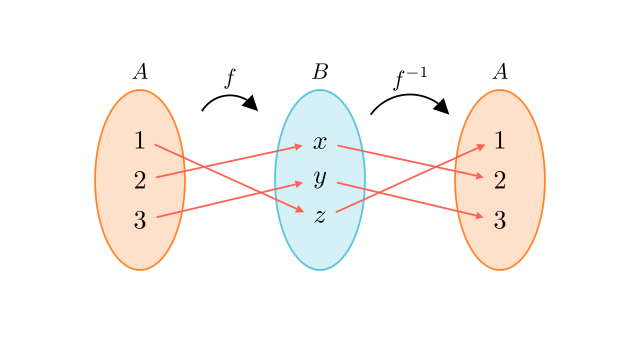

In [28]:
%%generate_image compose-function-with-inverse_aba FunctionDiagram

A_FONT_SIZE = 56  # TeX font size
A_COLOUR = ORANGE
B_FONT_SIZE = 56
B_COLOUR = BLUE

ARROW_STROKE_WIDTH = 4
ARROW_TIP_RATIO = 0.05
ARROW_COLOUR = RED

class FunctionDiagram(Scene):
    def construct(self):
        # Create the ellipses
        ellipse_a1 = Ellipse(width=2, height=4, color=A_COLOUR)
        ellipse_a1.set_fill(A_COLOUR, opacity=0.25)
        ellipse_a1.shift(4 * LEFT)
        
        ellipse_b = Ellipse(width=2, height=4, color=B_COLOUR)
        ellipse_b.set_fill(B_COLOUR, opacity=0.25)

        ellipse_a2 = Ellipse(width=2, height=4, color=A_COLOUR)
        ellipse_a2.set_fill(A_COLOUR, opacity=0.25)
        ellipse_a2.shift(4 * RIGHT)

        self.add(ellipse_a1, ellipse_b, ellipse_a2)
        
        # Create labels for the ellipses
        label_a1 = MathTex("A", color=BLACK).next_to(ellipse_a1, UP)
        label_b = MathTex("B", color=BLACK).next_to(ellipse_b, UP)
        label_a2 = MathTex("A", color=BLACK).next_to(ellipse_a2, UP)

        self.add(label_a1, label_b, label_a2)

        # Add function labels
        f_label = MathTex("f", color=BLACK).move_to(2*LEFT + 2.25*UP)
        f_label.add(
            CurvedArrow(
                f_label.get_left() + LEFT * 0.5,
                f_label.get_right() + RIGHT * 0.5,
                stroke_width=ARROW_STROKE_WIDTH,
                color=BLACK
            ).flip(LEFT).shift(DOWN * 0.35)
        )

        fi_label = MathTex("f^{-1}", color=BLACK).move_to(2*RIGHT + 2.25*UP)
        fi_label.add(
            CurvedArrow(
                fi_label.get_left() + LEFT * 0.5,
                fi_label.get_right() + RIGHT * 0.5,
                stroke_width=ARROW_STROKE_WIDTH,
                color=BLACK
            ).flip(LEFT).shift(DOWN * 0.35)
        )

        self.add(f_label, fi_label)

        # Create elements for sets
        elements_a = ["1", "2", "3"]
        elements_b = ["x", "y", "z"]

        elements_a1 = [MathTex(a, font_size=A_FONT_SIZE, color=BLACK) for a in elements_a]
        elements_b = [MathTex(b, font_size=B_FONT_SIZE, color=BLACK) for b in elements_b]
        elements_a2 = [MathTex(a, font_size=A_FONT_SIZE, color=BLACK) for a in elements_a]
        
        elements_a1 = VGroup(*elements_a1).arrange(DOWN, buff=0.5).move_to(ellipse_a1)
        elements_b = VGroup(*elements_b).arrange(DOWN, buff=0.5).move_to(ellipse_b)
        elements_a2 = VGroup(*elements_a2).arrange(DOWN, buff=0.5).move_to(ellipse_a2)

        self.add(elements_a1, elements_b, elements_a2)
        
        # Create arrows for A -> B
        arrow_links = [
            (0,2),
            (1,0),
            (2,1)
        ]
        arrows = [
            Arrow(
                elements_a1[i].get_right(),
                elements_b[j].get_left(),
                stroke_width=ARROW_STROKE_WIDTH,
                max_tip_length_to_length_ratio=ARROW_TIP_RATIO,
                color=RED
            )
            for i, j in arrow_links
        ]
        self.add(VGroup(*arrows))

        # Create arrows for B -> A
        arrows = [
            Arrow(
                elements_b[j].get_right(),
                elements_a2[i].get_left(),
                stroke_width=ARROW_STROKE_WIDTH,
                max_tip_length_to_length_ratio=ARROW_TIP_RATIO,
                color=RED
            )
            for i, j in arrow_links
        ]
        self.add(VGroup(*arrows))
        

Composition going $B \to A \to B$ (i.e., $f \circ f^{-1}$).

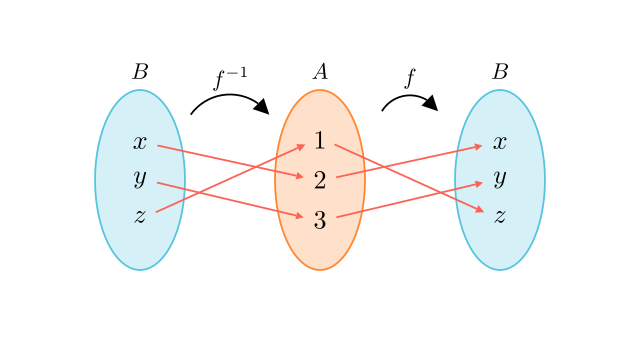

In [34]:
%%generate_image compose-function-with-inverse_bab FunctionDiagram

A_FONT_SIZE = 56  # TeX font size
A_COLOUR = ORANGE
B_FONT_SIZE = 56
B_COLOUR = BLUE

ARROW_STROKE_WIDTH = 4
ARROW_TIP_RATIO = 0.05
ARROW_COLOUR = RED

class FunctionDiagram(Scene):
    def construct(self):
        # Create the ellipses
        ellipse_b1 = Ellipse(width=2, height=4, color=B_COLOUR)
        ellipse_b1.set_fill(B_COLOUR, opacity=0.25)
        ellipse_b1.shift(4 * LEFT)
        
        ellipse_a = Ellipse(width=2, height=4, color=A_COLOUR)
        ellipse_a.set_fill(A_COLOUR, opacity=0.25)

        ellipse_b2 = Ellipse(width=2, height=4, color=B_COLOUR)
        ellipse_b2.set_fill(B_COLOUR, opacity=0.25)
        ellipse_b2.shift(4 * RIGHT)

        self.add(ellipse_b1, ellipse_a, ellipse_b2)
        
        # Create labels for the ellipses
        label_b1 = MathTex("B", color=BLACK).next_to(ellipse_b1, UP)
        label_a = MathTex("A", color=BLACK).next_to(ellipse_a, UP)
        label_b2 = MathTex("B", color=BLACK).next_to(ellipse_b2, UP)

        self.add(label_b1, label_a, label_b2)

        # Add function labels
        fi_label = MathTex("f^{-1}", color=BLACK).move_to(2*LEFT + 2.25*UP)
        fi_label.add(
            CurvedArrow(
                fi_label.get_left() + LEFT * 0.5,
                fi_label.get_right() + RIGHT * 0.5,
                stroke_width=ARROW_STROKE_WIDTH,
                color=BLACK
            ).flip(LEFT).shift(DOWN * 0.35)
        )

        f_label = MathTex("f", color=BLACK).move_to(2*RIGHT + 2.25*UP)
        f_label.add(
            CurvedArrow(
                f_label.get_left() + LEFT * 0.5,
                f_label.get_right() + RIGHT * 0.5,
                stroke_width=ARROW_STROKE_WIDTH,
                color=BLACK
            ).flip(LEFT).shift(DOWN * 0.35)
        )

        self.add(fi_label, f_label)

        # Create elements for sets
        elements_a = ["1", "2", "3"]
        elements_b = ["x", "y", "z"]

        elements_b1 = [MathTex(b, font_size=A_FONT_SIZE, color=BLACK) for b in elements_b]
        elements_a = [MathTex(a, font_size=B_FONT_SIZE, color=BLACK) for a in elements_a]
        elements_b2 = [MathTex(b, font_size=A_FONT_SIZE, color=BLACK) for b in elements_b]
        
        elements_b1 = VGroup(*elements_b1).arrange(DOWN, buff=0.5).move_to(ellipse_b1)
        elements_a = VGroup(*elements_a).arrange(DOWN, buff=0.5).move_to(ellipse_a)
        elements_b2 = VGroup(*elements_b2).arrange(DOWN, buff=0.5).move_to(ellipse_b2)

        self.add(elements_b1, elements_a, elements_b2)
        
        # Create arrows for B -> A
        arrow_links = [
            # These are for the function f; we will invert them later
            (0,2),
            (1,0),
            (2,1)
        ]
        arrows = [
            Arrow(
                elements_b1[j].get_right(),
                elements_a[i].get_left(),
                stroke_width=ARROW_STROKE_WIDTH,
                max_tip_length_to_length_ratio=ARROW_TIP_RATIO,
                color=RED
            )
            for i, j in arrow_links
        ]
        self.add(VGroup(*arrows))

        # Create arrows for A -> B
        arrows = [
            Arrow(
                elements_a[i].get_right(),
                elements_b2[j].get_left(),
                stroke_width=ARROW_STROKE_WIDTH,
                max_tip_length_to_length_ratio=ARROW_TIP_RATIO,
                color=RED
            )
            for i, j in arrow_links
        ]
        self.add(VGroup(*arrows))

### Composing Injective Functions

Showing the sets $A$, $B$, and $C$.

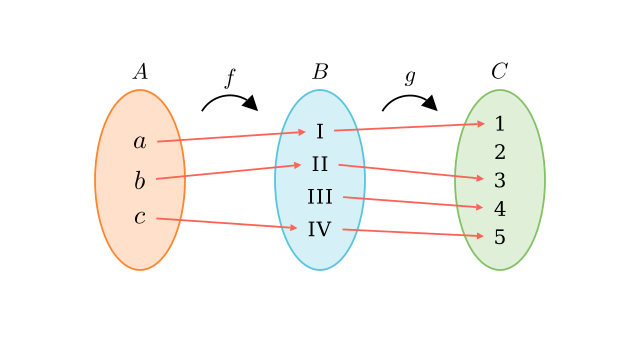

In [17]:
%%generate_image compose-injections_abc FunctionDiagram

A_FONT_SIZE = 56  # TeX font size
A_COLOUR = ORANGE
B_FONT_SIZE = 32  # Normal font size
B_COLOUR = BLUE
C_FONT_SIZE = 32  # Normal font size
C_COLOUR = GREEN

ARROW_STROKE_WIDTH = 4
ARROW_TIP_RATIO = 0.05
ARROW_COLOUR = RED

class FunctionDiagram(Scene):
    def construct(self):
        # Create the ellipses
        ellipse_a = Ellipse(width=2, height=4, color=A_COLOUR)
        ellipse_a.set_fill(A_COLOUR, opacity=0.25)
        ellipse_a.shift(4 * LEFT)
        
        ellipse_b = Ellipse(width=2, height=4, color=B_COLOUR)
        ellipse_b.set_fill(B_COLOUR, opacity=0.25)

        ellipse_c = Ellipse(width=2, height=4, color=C_COLOUR)
        ellipse_c.set_fill(C_COLOUR, opacity=0.25)
        ellipse_c.shift(4 * RIGHT)

        self.add(ellipse_a, ellipse_b, ellipse_c)
        
        # Create labels for the ellipses
        label_a = MathTex("A", color=BLACK).next_to(ellipse_a, UP)
        label_b = MathTex("B", color=BLACK).next_to(ellipse_b, UP)
        label_c = MathTex("C", color=BLACK).next_to(ellipse_c, UP)

        self.add(label_a, label_b, label_c)

        # Add function labels
        f_label = MathTex("f", color=BLACK).move_to(2*LEFT + 2.25*UP)
        f_label.add(
            CurvedArrow(
                f_label.get_left() + LEFT * 0.5,
                f_label.get_right() + RIGHT * 0.5,
                stroke_width=ARROW_STROKE_WIDTH,
                color=BLACK
            ).flip(LEFT).shift(DOWN * 0.35)
        )

        g_label = MathTex("g", color=BLACK).move_to(2*RIGHT + 2.25*UP)
        g_label.add(
            CurvedArrow(
                g_label.get_left() + LEFT * 0.5,
                g_label.get_right() + RIGHT * 0.5,
                stroke_width=ARROW_STROKE_WIDTH,
                color=BLACK
            ).flip(LEFT).shift(DOWN * 0.35)
        )

        self.add(f_label, g_label)

        # Create elements for sets
        elements_a = ["a", "b", "c"]
        elements_b = ["I", "II", "III", "IV"]
        elements_c = ["1", "2", "3", "4", "5"]

        elements_a = [MathTex(a, font_size=A_FONT_SIZE, color=BLACK) for a in elements_a]
        elements_b = [Text(b, font_size=B_FONT_SIZE, color=BLACK) for b in elements_b]
        elements_c = [Text(c, font_size=C_FONT_SIZE, color=BLACK) for c in elements_c]
        
        elements_a = VGroup(*elements_a).arrange(DOWN, buff=0.5).move_to(ellipse_a)
        elements_b = VGroup(*elements_b).arrange(DOWN, buff=0.4).move_to(ellipse_b)
        elements_c = VGroup(*elements_c).arrange(DOWN, buff=0.3).move_to(ellipse_c)

        self.add(elements_a, elements_b, elements_c)
        
        # Create arrows for A -> B
        arrow_links = [
            (0,0),
            (1,1),
            (2,3)
        ]
        arrows = [
            Arrow(
                elements_a[i].get_right(),
                elements_b[j].get_left(),
                stroke_width=ARROW_STROKE_WIDTH,
                max_tip_length_to_length_ratio=ARROW_TIP_RATIO,
                color=RED
            )
            for i, j in arrow_links
        ]
        self.add(VGroup(*arrows))

        # Create arrows for B -> C
        arrow_links = [
            (0,0),
            (1,2),
            (2,3),
            (3,4)
        ]
        arrows = [
            Arrow(
                elements_b[i].get_right(),
                elements_c[j].get_left(),
                stroke_width=ARROW_STROKE_WIDTH,
                max_tip_length_to_length_ratio=ARROW_TIP_RATIO,
                color=RED
            )
            for i, j in arrow_links
        ]
        self.add(VGroup(*arrows))
        

Showing the sets $A$ and $C$ only.

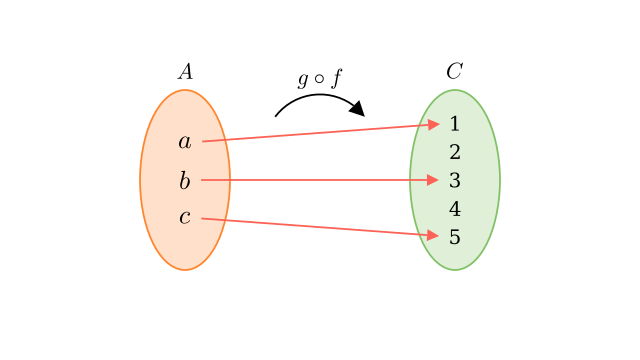

In [27]:
%%generate_image compose-injections_ac FunctionDiagram

A_FONT_SIZE = 56  # TeX font size
A_COLOUR = ORANGE
C_FONT_SIZE = 32  # Normal font size
C_COLOUR = GREEN

ARROW_STROKE_WIDTH = 4
ARROW_TIP_RATIO = 0.05
ARROW_COLOUR = RED

class FunctionDiagram(Scene):
    def construct(self):
        # Create the ellipses
        ellipse_a = Ellipse(width=2, height=4, color=A_COLOUR)
        ellipse_a.set_fill(A_COLOUR, opacity=0.25)
        ellipse_a.shift(3 * LEFT)

        ellipse_c = Ellipse(width=2, height=4, color=C_COLOUR)
        ellipse_c.set_fill(C_COLOUR, opacity=0.25)
        ellipse_c.shift(3 * RIGHT)

        self.add(ellipse_a, ellipse_c)
        
        # Create labels for the ellipses
        label_a = MathTex("A", color=BLACK).next_to(ellipse_a, UP)
        label_c = MathTex("C", color=BLACK).next_to(ellipse_c, UP)

        self.add(label_a, label_c)

        # Add function label
        gf_label = MathTex("g \\circ f", color=BLACK).move_to(2.25*UP)
        gf_label.add(
            CurvedArrow(
                gf_label.get_left() + LEFT * 0.5,
                gf_label.get_right() + RIGHT * 0.5,
                stroke_width=ARROW_STROKE_WIDTH,
                color=BLACK
            ).flip(LEFT).shift(DOWN * 0.35)
        )

        self.add(gf_label)

        # Create elements for sets
        elements_a = ["a", "b", "c"]
        elements_c = ["1", "2", "3", "4", "5"]

        elements_a = [MathTex(a, font_size=A_FONT_SIZE, color=BLACK) for a in elements_a]
        elements_c = [Text(c, font_size=C_FONT_SIZE, color=BLACK) for c in elements_c]
        
        elements_a = VGroup(*elements_a).arrange(DOWN, buff=0.5).move_to(ellipse_a)
        elements_c = VGroup(*elements_c).arrange(DOWN, buff=0.3).move_to(ellipse_c)

        self.add(elements_a, elements_c)
        
        # Create arrows for A -> C
        arrow_links = [
            (0,0),
            (1,2),
            (2,4)
        ]
        arrows = [
            Arrow(
                elements_a[i].get_right(),
                elements_c[j].get_left(),
                stroke_width=ARROW_STROKE_WIDTH,
                max_tip_length_to_length_ratio=ARROW_TIP_RATIO,
                color=RED
            )
            for i, j in arrow_links
        ]
        self.add(VGroup(*arrows))

### Composing Surjective Functions

Showing the sets $A$, $B$, and $C$.

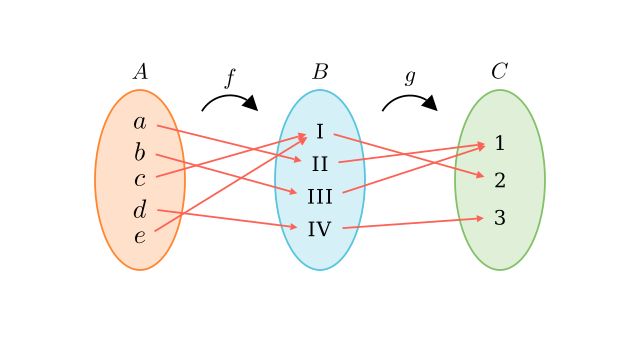

In [10]:
%%generate_image compose-surjections_abc FunctionDiagram

A_FONT_SIZE = 56  # TeX font size
A_COLOUR = ORANGE
B_FONT_SIZE = 32  # Normal font size
B_COLOUR = BLUE
C_FONT_SIZE = 32  # Normal font size
C_COLOUR = GREEN

ARROW_STROKE_WIDTH = 4
ARROW_TIP_RATIO = 0.05
ARROW_COLOUR = RED

class FunctionDiagram(Scene):
    def construct(self):
        # Create the ellipses
        ellipse_a = Ellipse(width=2, height=4, color=A_COLOUR)
        ellipse_a.set_fill(A_COLOUR, opacity=0.25)
        ellipse_a.shift(4 * LEFT)
        
        ellipse_b = Ellipse(width=2, height=4, color=B_COLOUR)
        ellipse_b.set_fill(B_COLOUR, opacity=0.25)

        ellipse_c = Ellipse(width=2, height=4, color=C_COLOUR)
        ellipse_c.set_fill(C_COLOUR, opacity=0.25)
        ellipse_c.shift(4 * RIGHT)

        self.add(ellipse_a, ellipse_b, ellipse_c)
        
        # Create labels for the ellipses
        label_a = MathTex("A", color=BLACK).next_to(ellipse_a, UP)
        label_b = MathTex("B", color=BLACK).next_to(ellipse_b, UP)
        label_c = MathTex("C", color=BLACK).next_to(ellipse_c, UP)

        self.add(label_a, label_b, label_c)

        # Add function labels
        f_label = MathTex("f", color=BLACK).move_to(2*LEFT + 2.25*UP)
        f_label.add(
            CurvedArrow(
                f_label.get_left() + LEFT * 0.5,
                f_label.get_right() + RIGHT * 0.5,
                stroke_width=ARROW_STROKE_WIDTH,
                color=BLACK
            ).flip(LEFT).shift(DOWN * 0.35)
        )

        g_label = MathTex("g", color=BLACK).move_to(2*RIGHT + 2.25*UP)
        g_label.add(
            CurvedArrow(
                g_label.get_left() + LEFT * 0.5,
                g_label.get_right() + RIGHT * 0.5,
                stroke_width=ARROW_STROKE_WIDTH,
                color=BLACK
            ).flip(LEFT).shift(DOWN * 0.35)
        )

        self.add(f_label, g_label)

        # Create elements for sets
        elements_a = ["a", "b", "c", "d", "e"]
        elements_b = ["I", "II", "III", "IV"]
        elements_c = ["1", "2", "3"]

        elements_a = [MathTex(a, font_size=A_FONT_SIZE, color=BLACK) for a in elements_a]
        elements_b = [Text(b, font_size=B_FONT_SIZE, color=BLACK) for b in elements_b]
        elements_c = [Text(c, font_size=C_FONT_SIZE, color=BLACK) for c in elements_c]
        
        elements_a = VGroup(*elements_a).arrange(DOWN, buff=0.3).move_to(ellipse_a)
        elements_b = VGroup(*elements_b).arrange(DOWN, buff=0.4).move_to(ellipse_b)
        elements_c = VGroup(*elements_c).arrange(DOWN, buff=0.5).move_to(ellipse_c)

        self.add(elements_a, elements_b, elements_c)
        
        # Create arrows for A -> B
        arrow_links = [
            (0,1),
            (1,2),
            (2,0),
            (3,3),
            (4,0)
        ]
        arrows = [
            Arrow(
                elements_a[i].get_right(),
                elements_b[j].get_left(),
                stroke_width=ARROW_STROKE_WIDTH,
                max_tip_length_to_length_ratio=ARROW_TIP_RATIO,
                color=RED
            )
            for i, j in arrow_links
        ]
        self.add(VGroup(*arrows))

        # Create arrows for B -> C
        arrow_links = [
            (0,1),
            (1,0),
            (2,0),
            (3,2)
        ]
        arrows = [
            Arrow(
                elements_b[i].get_right(),
                elements_c[j].get_left(),
                stroke_width=ARROW_STROKE_WIDTH,
                max_tip_length_to_length_ratio=ARROW_TIP_RATIO,
                color=RED
            )
            for i, j in arrow_links
        ]
        self.add(VGroup(*arrows))
        

Showing the sets $A$ and $C$ only.

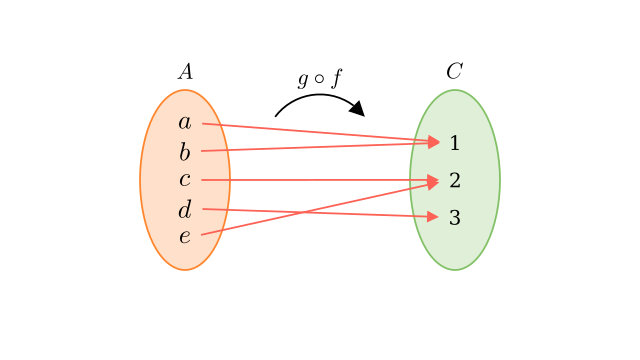

In [11]:
%%generate_image compose-surjections_ac FunctionDiagram

A_FONT_SIZE = 56  # TeX font size
A_COLOUR = ORANGE
C_FONT_SIZE = 32  # Normal font size
C_COLOUR = GREEN

ARROW_STROKE_WIDTH = 4
ARROW_TIP_RATIO = 0.05
ARROW_COLOUR = RED

class FunctionDiagram(Scene):
    def construct(self):
        # Create the ellipses
        ellipse_a = Ellipse(width=2, height=4, color=A_COLOUR)
        ellipse_a.set_fill(A_COLOUR, opacity=0.25)
        ellipse_a.shift(3 * LEFT)

        ellipse_c = Ellipse(width=2, height=4, color=C_COLOUR)
        ellipse_c.set_fill(C_COLOUR, opacity=0.25)
        ellipse_c.shift(3 * RIGHT)

        self.add(ellipse_a, ellipse_c)
        
        # Create labels for the ellipses
        label_a = MathTex("A", color=BLACK).next_to(ellipse_a, UP)
        label_c = MathTex("C", color=BLACK).next_to(ellipse_c, UP)

        self.add(label_a, label_c)

        # Add function label
        gf_label = MathTex("g \\circ f", color=BLACK).move_to(2.25*UP)
        gf_label.add(
            CurvedArrow(
                gf_label.get_left() + LEFT * 0.5,
                gf_label.get_right() + RIGHT * 0.5,
                stroke_width=ARROW_STROKE_WIDTH,
                color=BLACK
            ).flip(LEFT).shift(DOWN * 0.35)
        )

        self.add(gf_label)

        # Create elements for sets
        elements_a = ["a", "b", "c", "d", "e"]
        elements_c = ["1", "2", "3"]

        elements_a = [MathTex(a, font_size=A_FONT_SIZE, color=BLACK) for a in elements_a]
        elements_c = [Text(c, font_size=C_FONT_SIZE, color=BLACK) for c in elements_c]
        
        elements_a = VGroup(*elements_a).arrange(DOWN, buff=0.3).move_to(ellipse_a)
        elements_c = VGroup(*elements_c).arrange(DOWN, buff=0.5).move_to(ellipse_c)

        self.add(elements_a, elements_c)
        
        # Create arrows for A -> C
        arrow_links = [
            (0,0),
            (1,0),
            (2,1),
            (3,2),
            (4,1)
        ]
        arrows = [
            Arrow(
                elements_a[i].get_right(),
                elements_c[j].get_left(),
                stroke_width=ARROW_STROKE_WIDTH,
                max_tip_length_to_length_ratio=ARROW_TIP_RATIO,
                color=RED
            )
            for i, j in arrow_links
        ]
        self.add(VGroup(*arrows))